# Performing curation of all imodulons at once now.

- Based on GRN, OrthoICA, and functional annotation, metadata_boxplot, I will rename all imodulons all at once
- If manual changes to the imodulon names after new insights from subsequent analysis, go directly to the section: CHANGE iModulons after running other subsequent steps

In [1]:
from pymodulon.io import *
from pymodulon.plotting import *
from pymodulon.compare import compare_ica

from pymodulon.enrichment import compute_enrichment, compute_annotation_enrichment

import os
from os import path

import pandas as pd

import matplotlib.pyplot as plt

# 1. Perform the following analyses to characterize iModulons. If the characterization has previously been performed, go to step 2.

### path to different data

In [2]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

### different required data need to be loaded

In [3]:
ica_data = load_json_model(path.join(interim_dir,'ctherm_raw.json.gz'))

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [4]:
# GRN
df_grn_ica = pd.read_csv(path.join(interim_dir, 'grn_from_ica.tsv'), sep='\t', index_col=0)
df_grn_ica.set_index('index', inplace=True)

dict_grn_ica = df_grn_ica[['regulator']].to_dict()['regulator']

In [7]:
### orthologous ICAs
df_ortho_ica = pd.read_csv(path.join(external_dir, 'all_matches_imodulons_cthermocellum_orthoICA.tsv'), sep='\t', index_col=0)

# cutoff and then cluster them
df_ortho_ica_thres = df_ortho_ica.loc[df_ortho_ica['distance_pearson']>0.5]
# make sure I don't have any from GRN
df_ortho_ica_thres = df_ortho_ica_thres.loc[~df_ortho_ica_thres['imod_ctherm'].isin([k for k in dict_grn_ica.keys()])]


# also ensure the source is also provided
df_ortho_ica_thres['from_abbv'] = [k.split('_')[0][0].lower()+k.split('_')[-1][0].lower() for k in df_ortho_ica_thres['from'].to_list()]
df_ortho_ica_thres['imod_ref'] = df_ortho_ica_thres['imod_ref'] + '__' + df_ortho_ica_thres['from_abbv']

df_ortho_ica_thres_grouped = df_ortho_ica_thres.groupby('imod_ctherm')['imod_ref'].apply(list)

dict_ortho_ica_thres_grouped = df_ortho_ica_thres_grouped.to_dict()
dict_ortho_ica_thres_grouped

{8: ['SigD__bs', 'FliA__ec'],
 23: ['Arginine__ec'],
 25: ['Cysteine-1__ec', 'CysB-2__pa', 'CysB-3__pa'],
 27: ['stringent response__bs',
  'Translation__ec',
  'Unc_8__sp',
  'Translational-1__pa',
  'Translation-1__sa'],
 30: ['CysB-2__pa'],
 31: ['Rex__bs', 'Rex-2__sa'],
 40: ['Histidine__ec'],
 43: ['PyrR__bs', 'Pyrimidine__ec', 'PyrR__sp', 'PyrR__sa'],
 44: ['Ribose__ec'],
 49: ['Lrp__ec', 'Hot TALE 16__ec', 'Vir-1__sa', 'MgrA__sa'],
 51: ['G-box__bs', 'Purine__ec', 'PurR__sp', 'PurR__sa'],
 52: ['SwrA__bs']}

In [ ]:
# manually change the dictionary. If one organism, keep it. If multiple source, then don't
dict_ortho_ica_thres_grouped[8] = ['SigD', 'orthoICA', 'multiple'] #two sources
dict_ortho_ica_thres_grouped[23] = ['Arginine', 'orthoICA', 'ec'] #KEGG Module M00323 refers to the Urea transport system. Does not match Lrp from orthoICA
dict_ortho_ica_thres_grouped[25] = ['Cysteine-1', 'orthoICA', 'ec'] #makes sense
dict_ortho_ica_thres_grouped[27] = ['Translation', 'orthoICA', 'multiple'] #multiple
dict_ortho_ica_thres_grouped[30] = ['CysB-2', 'orthoICA', 'pa'] #Does not match Cysteine from orthoICA
dict_ortho_ica_thres_grouped[31] = ['Rex', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[40] = ['Histidine', 'orthoICA', 'ec']
dict_ortho_ica_thres_grouped[43] = ['PyrR', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[44] = ['Ribose', 'orthoICA', 'ec'] #M00212 is Ribose.
dict_ortho_ica_thres_grouped[49] = ['Vir-1', 'orthoICA', 'sa'] #highest this
dict_ortho_ica_thres_grouped[51] = ['PurR', 'orthoICA', 'multiple']
dict_ortho_ica_thres_grouped[52] = ['SwrA', 'orthoICA', 'bs']

In [16]:
### gene info
df_gene_info = pd.read_csv(path.join(data_dir, 'gene_info.csv'), index_col=0)
df_gene_info.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs
locus_tag,,,,,,,,,,,,,,
Clo1313_0001,dnaA,CP002416.1,NaN,212,1543,+,chromosomal replication initiator protein DnaA,No COG annotation,UPI0001B1F046,Op0,ATP binding; DNA replication origin binding; l...,DNA replication initiation; regulation of DNA ...,AAA+_ATPase;Chromosome_initiator_DnaA;Chromoso...,NaN
Clo1313_0002,RS00015,CP002416.1,NaN,1793,2893,+,DNA polymerase III%2C beta subunit,No COG annotation,UPI00017E1F7F,Op1,NaN,NaN,DNA_clamp_sf;DNA_polIII_beta;DNA_polIII_beta_C...,NaN
Clo1313_0003,yaaA,CP002416.1,NaN,2909,3115,+,S4 domain protein YaaA,No COG annotation,UPI000038F4E6,Op1,NaN,NaN,RNA-bd_S4-rel_YaaA;S4_RNA-bd;S4_RNA-bd_sf;,NaN
Clo1313_0004,recF,CP002416.1,NaN,3133,4242,+,DNA replication and repair protein RecF,No COG annotation,UPI00003C8C54,Op1,ATP binding; single-stranded DNA binding,DNA replication; DNA synthesis involved in DNA...,DNA-binding_RecF;DNA-binding_RecF_CS;P-loop_NT...,NaN
Clo1313_0005,RS00030,CP002416.1,NaN,4410,4724,+,hypothetical protein,Function unknown,UPI000038F4E8,Op2,NaN,NaN,RemA-like;,DUF370


In [ ]:
# dataframe with all the enrichment information
DF_enrichments = pd.read_csv(path.join(data_dir,'functional_enrichments.csv'),index_col=0)
DF_enrichments.head()

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
0,2,L-tryptophan biosynthesis,2.510499e-11,4.744843e-09,0.800000,0.666667,0.727273,4.0,6.0,5.0,biocyc,NaN,NaN
1,7,"(1,4)-&beta;-D-xylan degradation",9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
2,7,cellulose and hemicellulose degradation (cellu...,9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
3,10,fatty acid biosynthesis initiation (type II),6.927798e-07,1.309354e-04,0.230769,0.600000,0.333333,3.0,5.0,13.0,biocyc,NaN,NaN
4,10,even <i>iso</i>-branched-chain fatty acid bios...,3.849618e-06,3.637889e-04,0.230769,0.375000,0.285714,3.0,8.0,13.0,biocyc,NaN,NaN


### Add iModulon categories for regulatory ones
- DO not run this after finding all the imodulons. ica_data cannot be loaded with string indices
- This is only done to find the uncharacterized imodulons

In [ ]:
# # # rename the ones that are already from regulators
ica_data.rename_imodulons(dict_grn_ica)

# # # also use orthoICA
ica_data.rename_imodulons({k:v[0] for k ,v in dict_ortho_ica_thres_grouped.items()})


# GRN for regulation in C. thermocellum
for i,row in ica_data.imodulon_table.iterrows():
    if pd.notnull(row.regulator):
        ica_data.imodulon_table.loc[i, 'category'] = 'regulatory'
    elif pd.notnull(row.single_gene):
        ica_data.imodulon_table.loc[i, 'category'] = 'single_gene'
    else:
        if i in dict_ortho_ica_thres_grouped.keys() or i in dict_ortho_ica_thres_grouped.values():
            ica_data.imodulon_table.loc[i, 'category'] = 'orthoICA'
        else:
            ica_data.imodulon_table.loc[i, 'category'] = 'uncharacterized'

# Inspect all iModulons without the annotation from GRN or orthoICA

In [ ]:
unchar_imods = ica_data.imodulon_table[ica_data.imodulon_table.category == 'uncharacterized']
# we begin with the ones with highest variance
unchar_imods.sort_values('explained_variance', ascending=False)

In [21]:
for x in unchar_imods.index.to_list():
    try:
        annotation = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['annotation'].values[0]
        source = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['source'].values[0]
    except IndexError:
        annotation = ''
        source = ''

    print(x, annotation, source)

0 DDE_Tnp_1_3 pfam
1  
2 M00023 kegg_module
3  
5 map00970 kegg_pathway
6  
9  
10 fatty acid biosynthesis initiation (type II) biocyc
11 Transposase_mut pfam
12 M00212 kegg_module
13 pyruvate fermentation to acetate IV biocyc
14 HTH_21 pfam
15  
16 Glyco_hydro_9 interpro
18 LysM interpro
19 Transposase_mut pfam
20  
21 flavin biosynthesis I (bacteria and plants) biocyc
22 M00434 kegg_module
24  
26 ammonia assimilation cycle III biocyc
28 Thioredoxin-like_sf interpro
29  
32  
34  
35 M00121 kegg_module
36 M00245 kegg_module
37 dCache_1 pfam
38 M00299 kegg_module
39 FAD/NAD-binding_dom interpro
41 M00527 kegg_module
45 M00175 kegg_module
46 TetR_0692 GRN
47  
48 Beta-glucanase-like interpro
50  
53  
54 LexA_1449 GRN
55 peptidoglycan biosynthesis I (<I>meso</I>-diaminopimelate containing) biocyc
57  
58  
59 M00245 kegg_module
60 map00195 kegg_pathway
61  
62  
63 2Fe-2S_thioredx pfam
64  
65 M00506 kegg_module


### Now go through individual imodulons, for the ones that I could not identify through orthoICA or GRN. Iteratively went through each and then changed thresholds if needed

In [10]:
imod_of_interest = 66

# check for member genes
ica_data.view_imodulon(imod_of_interest).sort_values(['gene_weight', 'operon'], ascending=False).head(20)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_1882,0.122600,nuoF,CP002416.1,NaN,2200217,2202010,-,NADH dehydrogenase (quinone),Energy production and conversion,UPI000038F991,Op1289,NaN,NaN,4Fe4S_Fe-S-bd;4Fe4S_Fe_S_CS;NADH-UbQ_OxRdtase_...,2Fe-2S_thioredx;Complex1_51K;Fer4;NADH_4Fe-4S;...,Rex_2471
Clo1313_0023,0.122388,RS00130,CP002416.1,NaN,24124,25059,+,thiamine pyrophosphate TPP-binding domain-cont...,Energy production and conversion,UPI000038F4FA,Op15,NaN,NaN,PorB-like;THDP-binding;TPP_enzyme_TPP-bd;,TPP_enzyme_C,Rex_2471
Clo1313_0020,0.117593,RS00115,CP002416.1,NaN,22030,22608,+,pyruvate/ketoisovalerate oxidoreductase%2C gam...,Energy production and conversion,UPI000038F4F8,Op15,NaN,NaN,Oxidoreductase_gamma_subunit;PorC_KorC;Pyrv/ke...,POR,Rex_2471
Clo1313_0021,0.113949,RS00120,CP002416.1,NaN,22605,22910,+,pyruvate ferredoxin/flavodoxin oxidoreductase%...,Energy production and conversion,UPI00003C8C4C,Op15,NaN,NaN,4Fe4S_Fe-S-bd;4Fe4S_Fe_S_CS;PorD_KorD;,Fer4,Rex_2471
Clo1313_0022,0.111778,porA,CP002416.1,NaN,22927,24111,+,pyruvate flavodoxin/ferredoxin oxidoreductase ...,Energy production and conversion,UPI0001B1F042,Op15,NaN,NaN,PFOR_II;Pyruvate:ferred/Flavod_OxRd;Pyrv_Fd/Fl...,PFOR_II;POR_N,Rex_2471
Clo1313_1881,0.108640,RS09510,CP002416.1,NaN,2198449,2200197,-,hydrogenase%2C Fe-only,Energy production and conversion,UPI0001B1ED41,Op1289,NaN,NaN,2Fe-2S_ferredoxin-like_sf;2Fe-2S_ferredoxin-ty...,Fe_hyd_SSU;Fe_hyd_lg_C;Fer2_4;Fer4;Fer4_7;Fer4...,Rex_2471
Clo1313_1883,0.104996,RS09520,CP002416.1,NaN,2202043,2202411,-,ferredoxin,Energy production and conversion,UPI000038F992,Op1289,NaN,NaN,Thioredoxin-like_sf;,2Fe-2S_thioredx,Rex_2471
Clo1313_2354,-0.105666,RS11945,CP002416.1,NaN,2764458,2765564,-,extracellular solute-binding protein family 1,Inorganic ion transport and metabolism,UPI000038F8A8,Op1612,NaN,NaN,Ferric-bd;SBP;,SBP_bac_6;SBP_bac_8,NaN


In [ ]:
# use functional enrichments
DF_enrichments[DF_enrichments.imodulon==imod_of_interest].sort_values('f1score',ascending=False)

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
8,5,map00970,0.000042,0.00806,0.125,0.166667,0.142857,5.0,30.0,40.0,kegg_pathway,Aminoacyl-tRNA biosynthesis,NaN


<Axes: ylabel='5 iModulon\nActivity'>

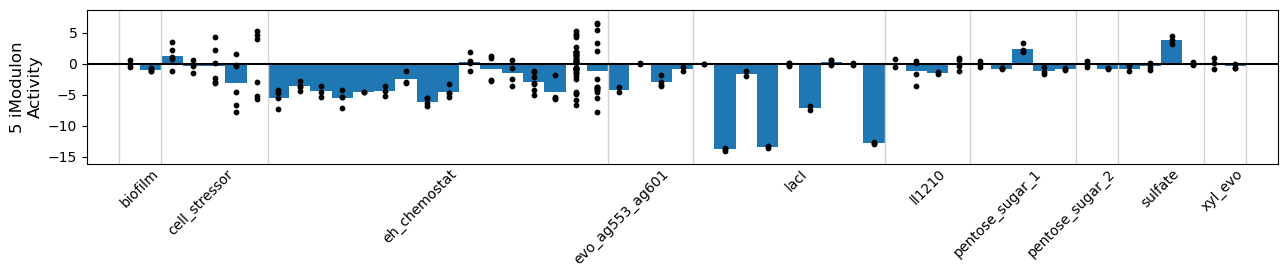

In [ ]:
# use plot activities
plot_activities(ica_data, imod_of_interest)

## Also, checking expression vs activity correlation to see if there are genes that might be possible regulators

In [ ]:
from scipy.stats import pearsonr, spearmanr

In [ ]:
df_metadata = ica_data.sample_table
df_expression = ica_data.X

df_corr = pd.DataFrame(columns=['corr', 'annotation'])

for loctag_interest in ica_data.view_imodulon(imod_of_interest).index.to_list():
    df_metadata_eh = df_metadata.copy()
    exp_of_interest = df_metadata_eh.index.to_list()
    df_expression_eh = df_expression[exp_of_interest]
    values = df_expression_eh.loc[loctag_interest, :]

    x = values
    y = ica_data.A[exp_of_interest].loc[imod_of_interest]

    corr, p = pearsonr(x,y)
    corr, p = np.round(corr, 2), np.round(p, 2)

    if p<0.05 and corr>=0.5:
        prod = df_gene_info.loc[loctag_interest, 'gene_product']
        df_corr.loc[loctag_interest]= corr, prod

df_corr.sort_values('corr', inplace=True, ascending=True)

# check the df_corr
df_corr

## Renaming single imodulons

In [ ]:
sg_imods = ica_data.imodulon_table[ica_data.imodulon_table.category == 'single_gene']

for x in sg_imods.index.to_list():
    size = sg_imods.loc[x, 'regulon_size']
    try:
        annotation = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['annotation'].values[0]
        source = DF_enrichments[DF_enrichments.imodulon==x].sort_values('f1score',ascending=False)['source'].values[0]
        
    except IndexError:
        annotation = ''
        source = ''

    print(x, size, annotation, source)

28 nan  
36 nan  
39 nan Beta_helix pfam
40 nan M00627 kegg_module


In [ ]:
dict_rename_sg_imod = {28: ['ldh KO', 'single_gene', ''],
                     36: ['hpt KO', 'single_gene', ''],
                     39: ['SG-0124', 'single_gene', ''],#dominated by Clo1313_1952
                     40: ['SG-2303', 'single_gene', ''],#dominated by Clo1313_2303 -- Glutamine and Urea
}

### Use metadata_boxplot to characterize iModulons

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/sklearn/tree/_classes.py:366: FutureWarning: Criterion 'mae' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='absolute_error'` which is equivalent.
  warnings.warn(


<Axes: xlabel='61'>

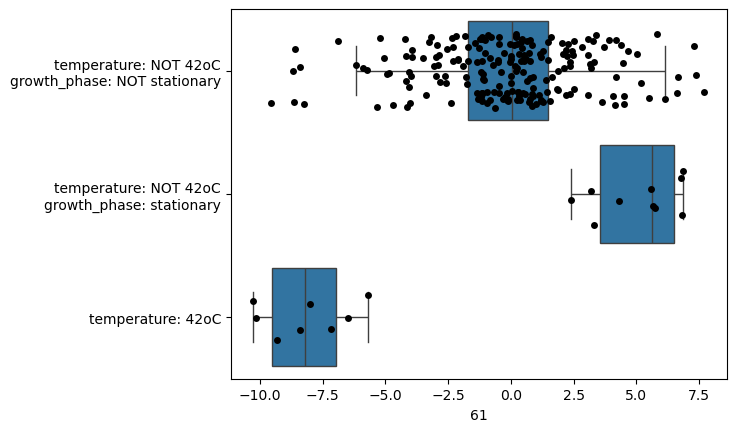

In [9]:
# Metadata boxplot
imod_of_interest = 61
metadata_boxplot(ica_data, imod_of_interest)

## Adjust some thresholds -- if no genes present in the IM

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Text(13.222222222222216, 0.5, 'Gene Weights')

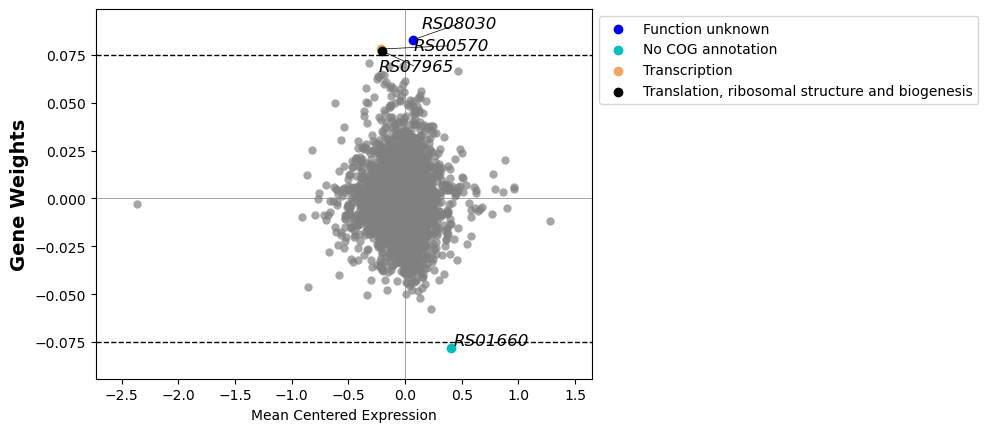

In [ ]:
imod_of_interest = 50
ax = plot_gene_weights(ica_data, imod_of_interest, by='log-tpm-norm')

labels_of_interest = list() #any labels that I would like to keep

ax.set_ylabel('Gene Weights', fontdict={'weight':'bold', 'size':14})

In [248]:
dict_change_threshold = {50: 0.075,
                        #  53: 0.075
                        }

for imod, new_thres in dict_change_threshold.items():
    ica_data.change_threshold(imod, new_thres)

# Recalculate enrichments
ica_data.compute_trn_enrichment([k for k in dict_change_threshold.keys()], save=True)

,imodulon,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs


In [ ]:
ica_data.view_imodulon(50)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0107,0.078106,RS00570,CP002416.1,NaN,122010,122453,+,transcriptional regulator%2C BadM/Rrf2 family,Transcription,UPI00003C8E1E,Op79,,,Tscrpt_reg_Rrf2;WH-like_DNA-bd_sf;WH_DNA-bd_sf;,Rrf2,
Clo1313_0322,-0.078103,RS01660,CP002416.1,NaN,353207,353581,+,hypothetical protein,No COG annotation,UPI000038FB52,Op214,,,,-,
Clo1313_1578,0.077329,RS07965,CP002416.1,NaN,1835747,1837387,+,glutamyl-tRNA synthetase,"Translation, ribosomal structure and biogenesis",UPI00003C8F4E,Op1095,,,aa-tRNA-synth_I_cd-bd;aa-tRNA-synth_I_codon-bd...,tRNA-synt_1c,AraC_0222
Clo1313_1591,0.082888,RS08030,CP002416.1,NaN,1855017,1855265,+,hypothetical protein,Function unknown,UPI00003C8CA0,Op1105,,,Ubiquitin-like_dom;Ubiquitin-like_domsf;YukD-l...,YukD,


## Now manually rename dictioanry that will be used to create the final DF. Update this dictionary as per your need

In [ ]:
dict_rename_imod = {
                    0: ['DDE_Tnp_1_3', 'functional', 'pfam'],
                    1: ['SigG', 'functional', 'activity_expression_genes_present'],
                    2: ['Tryptophan', 'functional', 'kegg']
                    3: ['UC', '', ''],
                    5: ['Translation-1', 'functional', 'genes_present'],
                    6: ['AbrB', 'functional', 'activity_expression_genes_present']
                    7: 
                    4: ['UC', '', ''],
                    5: ['Pentose', 'functional', 'kegg'], #looks like pentose sugar metabolism Clo1313_0073-Clo1313_0080
                    8: ['UC', '', ''], 
                    9: ['Heme-1', 'functional', 'kegg'], 
                    10: ['Tryptophan', 'functional', 'kegg'],
                    11: ['Lysine-1', 'functional', 'kegg'],
                    12: ['UC', '', ''],
                    13: ['Chemotaxis', 'functional', 'kegg'],
                    14: ['Fe-S-Related', 'functional', 'genes_present'], #related to iron-sulfur binding, it seems
                    15: ['F-ATPase', 'functional', 'genes_present'], 
                    16: ['AbrB-Related', 'functional', 'genes_present'], 
                    18: ['FABI-III/FapR', 'functional', 'biocyc'], #could be fapR associated
                    19: ['UC', '', ''], 
                    20: ['Thioredoxin-SF', 'functional', 'interpro'], #very low activity in biofilms
                    21: ['UC', '', ''], 
                    22: ['UC', '', ''], 
                    23: ['DDE_Tnp_1_3', 'functional', 'pfam'], #esponsible for coordinating metal ions needed for catalysis
                    24: ['Transposase-1', 'functional', 'pfam/cog'],
                    26: ['Lysine-2', 'functional', 'kegg'],
                    27: ['Ribosome-1', 'functional', 'kegg'],
                    30: ['Co/Ni-tp-1', 'functional', 'kegg'], 
                    32: ['N2Fix', 'functional', 'kegg'],
                    33: ['GH_16', 'functional', 'pfam'],
                    34: ['Motility', 'functional', 'cog'],
                    38: ['Transposase-2', 'functional', 'pfam/cog'],
                    41: ['TetR_0692', 'regulatory', 'GRN'],
                    42: ['Thiamine', 'functional', 'biocyc/kegg'],
                    43: ['PyrAc', 'functional', 'biocyc'],
                    45: ['UC', '', ''], 
                    47: ['FAD/NAD-binding', 'functional', 'interpro'], 
                    48: ['Heme', 'functional', 'kegg'], 
                    49: ['GH9', 'functional', 'interpro'], 
                    50: ['UC', '', ''], 
                    51: ['tRNA', 'functional', 'kegg'],
                    52: ['LexA_1449', 'regulatory', 'GRN'],
                    54: ['Spmd/Ptrc-tp', 'functional', 'kegg'], #M00299 is the module of the spermidine/putrescine transport system
                    55: ['SO4-tp', 'functional', 'kegg'],
                    56: ['Transposase-3', 'functional', 'pfam'],
                    57: ['GlyR1-Sta', 'activity_boxplot', 'metadata_boxplot'],
                    58: ['UC', '', ''],
                    60: ['Co/Ni-tp-2', 'functional', 'kegg'], 
                    61: ['HighTemp-Sta', 'activity_boxplot', 'metadata_boxplot'],
                    62: ['UC', '', ''],
                    63: ['NADHOx', 'functional', 'kegg'],
                    64: ['UC', '', ''],
                    65: ['CheR-Related', 'functional', 'activity_expression_genes_present']
}


## Merge all renaming dictionaries and then create DF to save

In [ ]:
# first make sure formatting is similar for GRN and orthoICA dictionaries
for k,v in dict_grn_ica.items():
    dict_grn_ica[k] = [v, 'regulatory', '']

for k,v in dict_ortho_ica_thres_grouped.items():
    dict_ortho_ica_thres_grouped[k] = [v, 'orthoICA', '']

In [295]:
# then update all at once
dict_rename_imod.update(dict_grn_ica)
dict_rename_imod.update(dict_ortho_ica_thres_grouped)
dict_rename_imod.update(dict_rename_sg_imod)

In [326]:
# then create the mapping
df_rename_imod = pd.DataFrame.from_dict(dict_rename_imod, orient='index', columns = ['IM', 'category', 'source'])

# Generate counts for each occurrence of UC
counts = df_rename_imod.groupby('IM').cumcount()
counts += 1

# # Add the count as a suffix
df_rename_imod['IM'] = df_rename_imod['IM'] + counts.map(lambda x: f'-{x}' if x > 1 else '')
df_rename_imod.loc[df_rename_imod['IM']=='UC', 'IM'] = 'UC-1'

# fill category with uncharacterized
df_rename_imod.loc[df_rename_imod['IM'].str.match(r'^UC-\d+'), 'category'] = 'uncharacterized'

In [328]:
### save
df_rename_imod.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

# Save final ICA data object as the gene thresholds have changed -- Don't save it for now. Do not change thresholds, if not needed.

In [331]:
save_to_json(ica_data, path.join(data_dir, 'ctherm.json.gz')) #adjusted
ica_data.imodulon_table.to_csv(path.join(data_dir, 'imodulon_table.csv'))

# 2. If after subsequent analysis, Icadata object needs to be changed, directly load them here

In [2]:
import pandas as pd
from os import path

In [3]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

In [6]:
df_rename_imod = pd.read_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

In [ ]:
# create a dictionary to rename IMs
dict_rename = {'SO4-tp': 'Sulfate'
}

In [12]:
# rename here
for k,v in dict_rename.items():
    df_rename_imod.loc[df_rename_imod.IM==k, 'IM'] = v

In [15]:
# checking
for k,v in dict_rename.items():
    print(k, df_rename_imod.loc[df_rename_imod.IM==k])
    print(v, df_rename_imod.loc[df_rename_imod.IM==v])


SO4-tp Empty DataFrame
Columns: [IM, category, source]
Index: []
Sulfate          IM    category source
55  Sulfate  functional   kegg


In [ ]:
### save again
df_rename_imod.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

## FIN